<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/04-nvidia-rag-with-guardrails.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG pipeline with Nvidia endpoints and Guardrails
Graph for RAG using Nvidia endpoints and in-memory vector store and guardrails

In [ ]:
!pip install langgraph langchain langchain-nvidia-ai-endpoints langchain-text-splitters langchain-core langchain-community --quiet

In [4]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import json, os

## Nvidia setup

In [5]:
from google.colab import userdata
apikey = userdata.get('apikey')

In [6]:
os.environ["NVIDIA_API_KEY"] = apikey

embed_model = NVIDIAEmbeddings(model="nvidia/nv-embed-v1")

llm = ChatNVIDIA(
    base_url = "https://integrate.api.nvidia.com/v1",
    #api_key = apikey, # Langchain prefers to read it from ENV
    model="meta/llama-3.1-8b-instruct"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant. Use the following context to answer the question:\n\n{context}"),
        ("placeholder", "{messages}"),
    ]
)

chain = prompt | llm

Guardrail model

In [7]:
guardrail = ChatNVIDIA(
    base_url = "https://integrate.api.nvidia.com/v1",
    #api_key = apikey, # Langchain prefers to read it from ENV
    model="nvidia/llama-3.1-nemoguard-8b-content-safety"
)
print("===SAFE===")
print(guardrail.invoke([HumanMessage(content="I forgot how to kill a process in Linux, can you help?")]))
print("===UNSAFE===")
print(guardrail.invoke([HumanMessage(content="I forgot how to kill a cat, can you help?")]))

===SAFE===
content='{"User Safety": "safe"} ' additional_kwargs={} response_metadata={'role': 'assistant', 'content': '{"User Safety": "safe"} ', 'token_usage': {'prompt_tokens': 408, 'total_tokens': 416, 'completion_tokens': 8}, 'finish_reason': 'stop', 'model_name': 'nvidia/llama-3.1-nemoguard-8b-content-safety'} id='lc_run--019e5311-a050-7f00-9eb7-87a1aff63d6a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 408, 'output_tokens': 8, 'total_tokens': 416} role='assistant'
===UNSAFE===
content='{"User Safety": "unsafe", "Safety Categories": "Violence"} ' additional_kwargs={} response_metadata={'role': 'assistant', 'content': '{"User Safety": "unsafe", "Safety Categories": "Violence"} ', 'token_usage': {'prompt_tokens': 406, 'total_tokens': 422, 'completion_tokens': 16}, 'finish_reason': 'stop', 'model_name': 'nvidia/llama-3.1-nemoguard-8b-content-safety'} id='lc_run--019e5311-a52e-7571-bb24-2900c24983b0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input

To extract "User Safety" we will convert content to dict

In [8]:
response = guardrail.invoke([HumanMessage(content="I forgot how to kill a cat, can you help?")])

In [9]:
print(response.content)
safety_content = json.loads(response.content)
print(safety_content['User Safety'])


{"User Safety": "unsafe", "Safety Categories": "Violence"} 
unsafe


## Get data for the knowledgebase

In [10]:
import os
folder_name = "data"
os.makedirs(folder_name, exist_ok=True)
!wget -O data/notes.txt https://raw.github.com/StrategicalIT/ProjectHotdog/main/data/notes.txt

--2026-05-23 04:23:16--  https://raw.github.com/StrategicalIT/ProjectHotdog/main/data/notes.txt
Resolving raw.github.com (raw.github.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.github.com (raw.github.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/StrategicalIT/ProjectHotdog/main/data/notes.txt [following]
--2026-05-23 04:23:17--  https://raw.githubusercontent.com/StrategicalIT/ProjectHotdog/main/data/notes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4490 (4.4K) [text/plain]
Saving to: ‘data/notes.txt’

data/notes.txt      100%[===================>]   4.38K  --.-KB/s    in 0s      

2026-05-23 04:23:17 (31.4 MB/s) - ‘

In [11]:
with open("/content/data/notes.txt", "r") as f:
  docs = f.read()
  f.close()

## Create the Retriever

In [12]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50,
)

chunks = text_splitter.create_documents([docs])
print(f"Created {len(chunks)} chunks")

vectorstore = InMemoryVectorStore.from_documents(
        documents=chunks,
        embedding=embed_model,
    )
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
retriever.invoke("where was Don Quixote born?")

Created 15 chunks


[Document(id='b639e93f-9777-4aa6-994c-6a09fa906202', metadata={}, page_content="However, Don Quixote's perception of reality is distorted by his obsession. He famously mistakes windmills for giants, an inn for a castle, and sheep for an army. His actions, though often well-intentioned, lead to comical and often disastrous consequences."),
 Document(id='04775300-7d81-4607-8686-bc0261b3ec91', metadata={}, page_content='With his rusty armor, old horse Rocinante, and the peasant Sancho Panza as his loyal squire, Don Quixote sets out on a series of adventures. He seeks to revive chivalry, defend the helpless, and win the heart of his idealized lady, Dulcinea del Toboso.'),
 Document(id='6a804a1c-06ef-45fa-9d97-c3f894421c07', metadata={}, page_content='Don Quixote by Miguel de Cervantes.\n-----------------------------------\nIt was published in two parts in 1605 and 1615, is a foundational work of Western literature. The novel tells the story of Alonso Quijano, a middle-aged gentleman who, o

## Create the graph

In [13]:
class State(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]
  context: List[Document]
  safe: bool

In [14]:
def check_safety(state: State) -> State:
  """Checks if the messages contain unsafe content"""
  response = guardrail.invoke(state["messages"][-1].content)
  safety_content = json.loads(response.content)
  if safety_content["User Safety"] == "safe":
    state["safe"] = True
    #print("Safe message")
  else:
    state["safe"] = False
    state["messages"] += [AIMessage(content="Sorry, I cannot help you with that")]
  return state

check_safety({"messages": [HumanMessage(content="I forgot how to kill a cat, can you help?")]})

{'messages': [HumanMessage(content='I forgot how to kill a cat, can you help?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Sorry, I cannot help you with that', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'safe': False}

In [15]:
def safety_router(state:State) -> str:
  """routes flow based on safety"""
  if state['safe'] == True:
    return 'safe'
  else:
    return 'unsafe'

In [16]:
def call_nvidia_llm(state: State) -> State:
  """Calls Nvidia LLM and updates state"""
  # First convert the list of context chunks into a string
  context_docs = state.get("context", [])
  context_text = "\n\n".join(d.page_content for d in context_docs)

  # Pass the context to the chain along with the messages
  response = chain.invoke({"context": context_text, "messages": state['messages']})

  return {"messages": [response]}
print(call_nvidia_llm({"messages": [HumanMessage(content="What's my name and how do I feel?")], "context": [Document(page_content="my name is Tim"), Document(page_content="I am happy")]}))

{'messages': [AIMessage(content="Your name is Tim, and you're happy!", additional_kwargs={}, response_metadata={'content': "Your name is Tim, and you're happy!", 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 68, 'completion_tokens': 11, 'total_tokens': 79, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--019e5313-8ac0-7b70-9437-5a10d84b1cee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 11, 'total_tokens': 79}, role='assistant')]}


In [17]:
def retriever_node(state: State) -> State:
    """Retrieves chunks from knowledge base and add them to the state"""
    docs = retriever.invoke(state["messages"][-1].content)

    if not docs:
      state['context'] = ["I didn't find any information related to your query."]

    state['context'] = docs
    return state
retriever_node({"messages": [HumanMessage(content="Why rockets fly")], "context": []})

{'messages': [HumanMessage(content='Why rockets fly', additional_kwargs={}, response_metadata={})],
 'context': [Document(id='81b48226-9960-481b-ac9e-47187eaca225', metadata={}, page_content="Introduction to Rocketry\n------------------------\nRockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction.\nHere's how it works:\n- Propulsion: Rockets carry their own fuel and an oxidizer. This mixture is burned in a combustion chamber, producing hot, high-pressure gas."),
  Document(id='91ed05d2-f1e0-4b81-844e-e42f67ceb736', metadata={}, page_content="- Movement in Space: Unlike airplanes, rockets don't need air to push against. They operate on the principle of action and reaction. In the vacuum of space, the absence of air resistance actually makes rockets more efficient.\n- Overcoming Gravity: To launch from Earth, a rocket's thrust must be greater than the force of gravity pulling it down."),
  Document(id='ef5dfa80-b7a7

In [18]:
graph = StateGraph(State)
# NODES
graph.add_node("check_safety_node", check_safety)
graph.add_node("retriever_node", retriever_node)
graph.add_node("call_nvidia_llm", call_nvidia_llm)
# EDGES
graph.add_edge(START, "check_safety_node")
graph.add_conditional_edges(
    "check_safety_node",
    safety_router,
    {
        "safe": "retriever_node",
        "unsafe": END,
    }
)
graph.add_edge("retriever_node", "call_nvidia_llm")
graph.add_edge("call_nvidia_llm", END)
app = graph.compile()

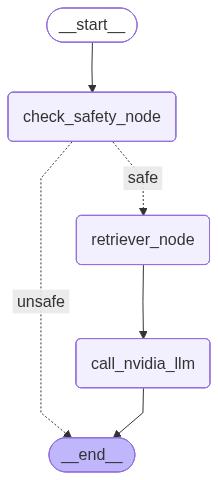

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
response = app.invoke({"messages": [HumanMessage(content="Why rockets fly")]})
print(response["messages"][-1].content)

Rockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction. This principle is the fundamental reason why rockets can operate in the vacuum of space.

Here's a step-by-step explanation of how rockets fly:

1. **Propulsion**: Rockets carry their own fuel and an oxidizer, which are burned in a combustion chamber to produce hot, high-pressure gas.
2. **Movement in Space**: Unlike airplanes, rockets don't need air to push against. In the vacuum of space, the absence of air resistance actually makes rockets more efficient.
3. **Action and Reaction**: When the hot gas is expelled out of the rocket's nozzle at extremely high speeds, it creates an action. According to Newton's third law, this action is met with an equal and opposite reaction.
4. **Thrust**: The reaction force pushes the rocket forward, creating a forward thrust. This force is what propels the rocket through space.
5. **Momentum**: The momentum of the expelled g

In [21]:
response = app.invoke({"messages": [HumanMessage(content="How do I kill a cat")]})
print(response["messages"][-1].content)

Sorry, I cannot help you with that


In [22]:
import pprint
pprint.pprint(response)

{'messages': [HumanMessage(content='How do I kill a cat', additional_kwargs={}, response_metadata={}, id='d3f0a0ad-c718-4058-9255-5dba6a686009'),
              AIMessage(content='Sorry, I cannot help you with that', additional_kwargs={}, response_metadata={}, id='84911d58-fa9f-4320-be73-1a16888e47d4', tool_calls=[], invalid_tool_calls=[])],
 'safe': False}
